# Task 1: Improve Model from Worksheet 5

## Step 1: Import Required Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
                                      Dropout, BatchNormalization, Activation)

## Step 2: Data Understanding and Visualization

### 2.1 Verify Dataset Directory Structure

In [2]:
# Define dataset path
train_dir = "/content/drive/MyDrive/Machine Learning/Week5/FruitinAmazon/train"  # Replace with your actual path

# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### 2.2 Check for Corrupted Images

In [3]:
corrupted_images = []  # List to store corrupted images path

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
    # Optional: Delete corrupted images
    for img_path in corrupted_images:
        os.remove(img_path)
        print(f"Deleted: {img_path}")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### 2.3 Check Class Balance

In [4]:
# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                 if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


### 2.4 Visualize Random Images from Each Class

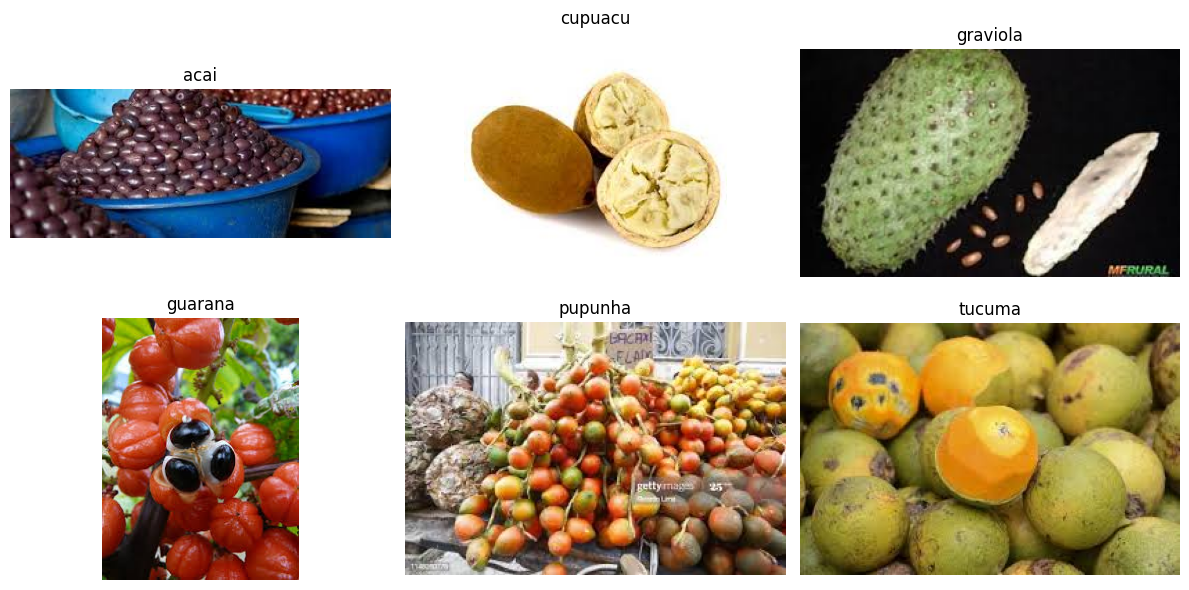

In [5]:
# Select random images
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                 if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot random images
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

## Step 3: Data Generation and Preprocessing

### 3.1 Generate Train and Validation Datasets

In [6]:
# Define image size and batch size
image_size = (224, 224)  # Adjust based on your dataset
batch_size = 32

# Generate datasets with 20% validation split
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

# Check the shape of one batch
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


### 3.2 Visualize Training Dataset

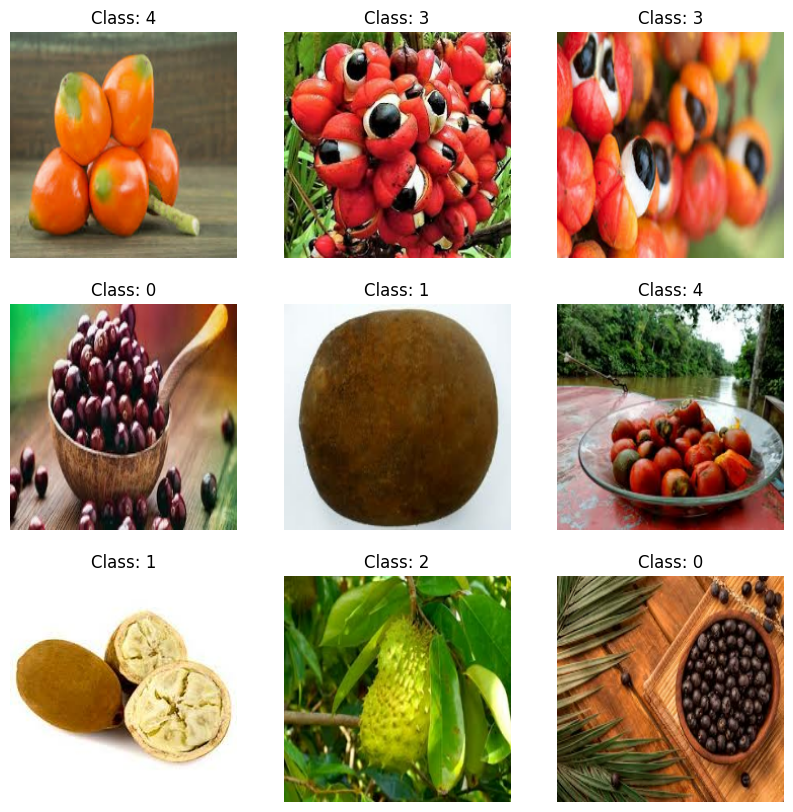

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(f"Class: {int(labels[i])}")
        plt.axis("off")
plt.show()

### 3.3 Define Data Augmentation Layers

In [8]:
# Define augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

### 3.4 Visualize Augmented Images

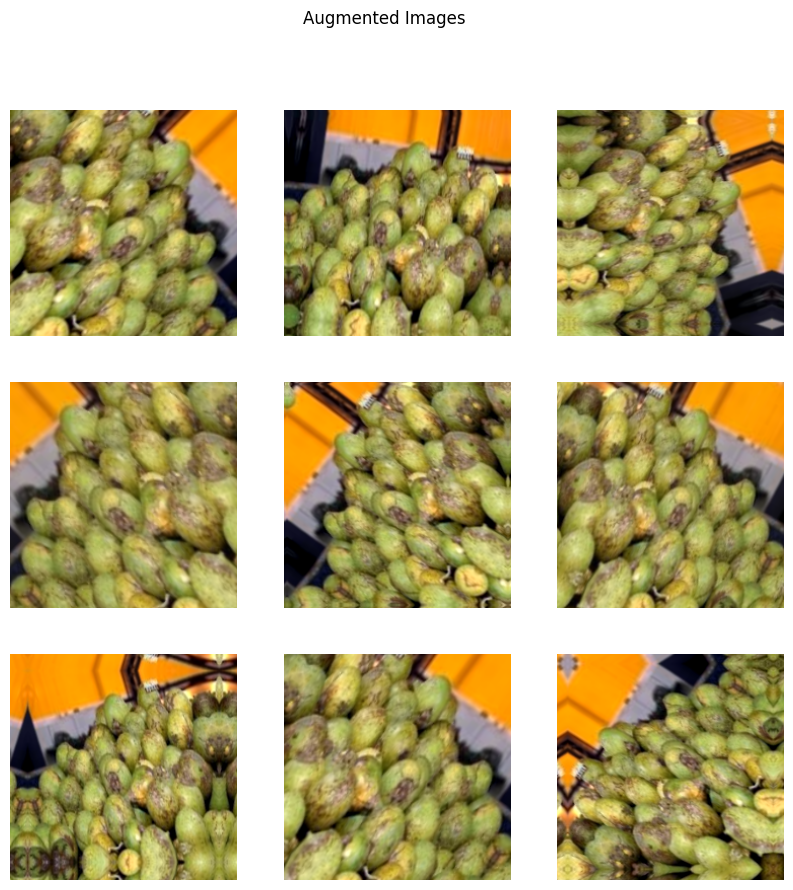

In [9]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Images")
plt.show()

## Step 4: Build Improved CNN Model with BatchNormalization and Dropout

In [10]:
# Define the improved model
model = Sequential([
    # Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),

    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer (adjust num_classes based on your dataset)
    Dense(len(class_names), activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

## Step 5: Calculate Model Parameters

In [11]:
def calculate_conv_params(F, C_in, K):
    """
    Calculate parameters in a convolutional layer.
    F: Filter size (e.g., 3 for 3x3)
    C_in: Number of input channels
    K: Number of filters (output channels)
    """
    return (F * F * C_in + 1) * K

def calculate_bn_params(K):
    """
    Calculate parameters in a Batch Normalization layer.
    K: Number of channels
    """
    return 2 * K

def calculate_fc_params(input_units, output_units):
    """
    Calculate parameters in a Fully Connected layer.
    """
    return (input_units + 1) * output_units

# Example calculation for first Conv2D layer:
# F=3, C_in=3 (RGB), K=32
params_conv1 = calculate_conv_params(3, 3, 32)
print(f"Conv2D Layer 1 Parameters: {params_conv1}")

# BatchNormalization after Conv2D (K=32)
params_bn1 = calculate_bn_params(32)
print(f"BatchNorm Layer 1 Parameters: {params_bn1}")

Conv2D Layer 1 Parameters: 896
BatchNorm Layer 1 Parameters: 64


## Step 6: Train the Model

In [12]:
# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Train the model
epochs = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.1250 - loss: 2.6884 - val_accuracy: 0.1111 - val_loss: 1.7828 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.2361 - loss: 2.0736 - val_accuracy: 0.2222 - val_loss: 1.7420 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.3333 - loss: 2.0874 - val_accuracy: 0.3333 - val_loss: 1.7285 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.2361 - loss: 1.9963 - val_accuracy: 0.2778 - val_loss: 1.7326 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.2639 - loss: 1.8899 - val_accuracy: 0.2778 - val_loss: 1.7284 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.3472 - loss: 1.7068 - val_accuracy: 0.4444 - val_loss: 1.7575 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.3194 - loss: 1.7205 - val_accuracy: 0.2778 - val_l

## Step 7: Visualize Training History

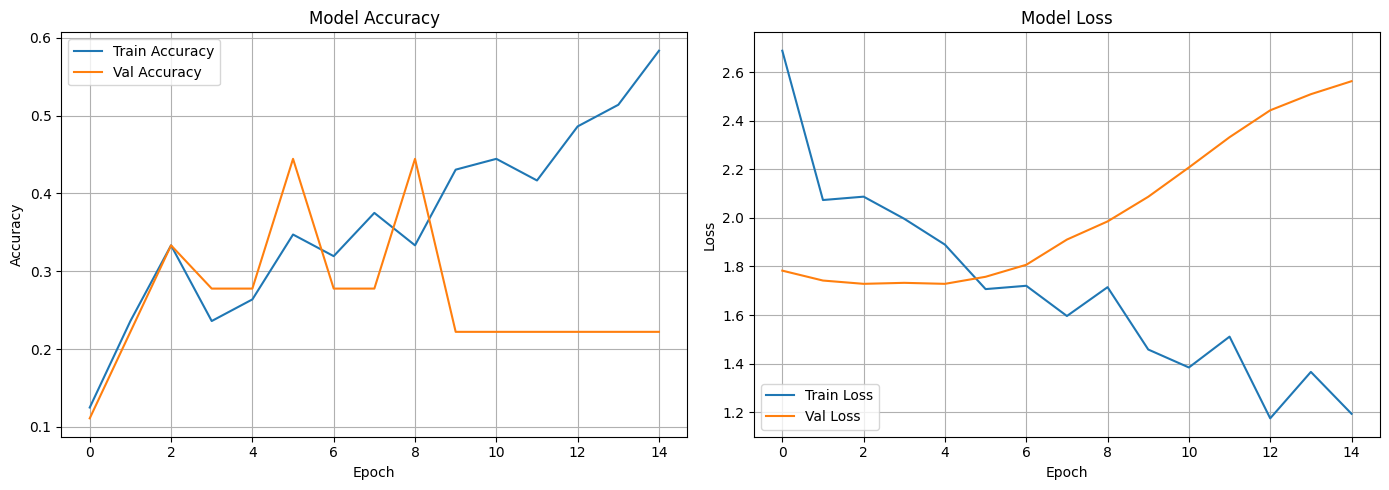

In [13]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## Step 8: Evaluate the Model

In [14]:
# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step - accuracy: 0.2778 - loss: 1.7284

Validation Loss: 1.7284
Validation Accuracy: 0.2778


## Step 9: Make Predictions and Generate Classification Report


Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.33      0.75      0.46         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.22      0.40      0.29         5

    accuracy                           0.28        18
   macro avg       0.09      0.19      0.12        18
weighted avg       0.14      0.28      0.18        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


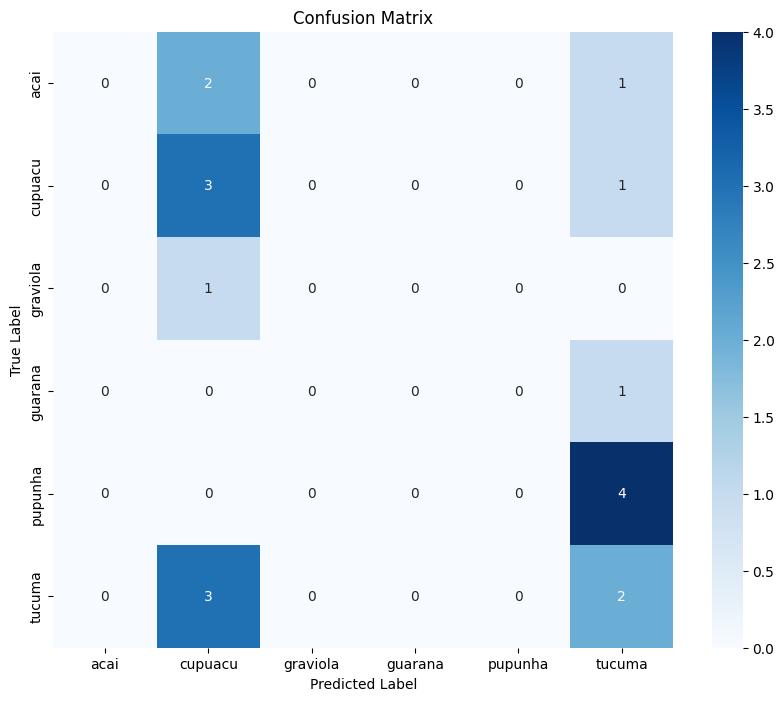

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 10: Save the Model

In [16]:
# Save the trained model
model.save('improved_cnn_model.h5')
print("Model saved successfully!")

Model saved successfully!


# Task 2: Transfer Learning with VGG16

## Step 1: Load Pre-trained VGG16 Model

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# Load VGG16 without top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 base model loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base model loaded successfully!


## Step 2: Freeze Base Model Layers


In [18]:
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

print("All VGG16 layers frozen.")

All VGG16 layers frozen.


## Step 3: Add Custom Classification Layers


In [19]:
from tensorflow.keras.layers import GlobalAveragePooling2D

# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce spatial dimensions
x = Dense(1024, activation='relu')(x)  # FC layer with 1024 neurons
x = Dropout(0.5)(x)  # Dropout for regularization
x = Dense(512, activation='relu')(x)  # Another FC layer
x = Dropout(0.5)(x)
x = Dense(len(class_names), activation='softmax')(x)  # Output layer

# Create the final model
transfer_model = Model(inputs=base_model.input, outputs=x)

print("Custom layers added successfully!")

Custom layers added successfully!


## Step 4: Compile the Transfer Learning Model

In [20]:
from tensorflow.keras.optimizers import Adam

# Compile the model
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,767,878 (60.15 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 5: Train the Transfer Learning Model


In [21]:
# Define callbacks
early_stopping_tl = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_tl = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Train the model
epochs_tl = 30

history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_tl,
    callbacks=[early_stopping_tl, reduce_lr_tl],
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.1528 - loss: 9.3593 - val_accuracy: 0.0556 - val_loss: 4.3135 - learning_rate: 1.0000e-04
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 17s/step - accuracy: 0.2361 - loss: 6.6230 - val_accuracy: 0.0556 - val_loss: 3.3238 - learning_rate: 1.0000e-04
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 21s/step - accuracy: 0.2778 - loss: 6.0845 - val_accuracy: 0.1667 - val_loss: 3.3206 - learning_rate: 1.0000e-04
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 17s/step - accuracy: 0.2917 - loss: 5.8186 - val_accuracy: 0.1667 - val_loss: 3.4334 - learning_rate: 1.0000e-04
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 20s/step - accuracy: 0.2639 - loss: 6.1410 - val_accuracy: 0.1111 - val_loss: 3.3515 - learning_rate: 1.0000e-04
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 20s/step - accuracy: 0.3056 - loss: 5.6733 - val_accuracy: 0.1667 - val_loss: 3.1757 - learning_rate: 1.0000e-04
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 16s/step - accuracy: 0.3750 - loss: 4.9370

## Step 6: Visualize Transfer Learning Training History


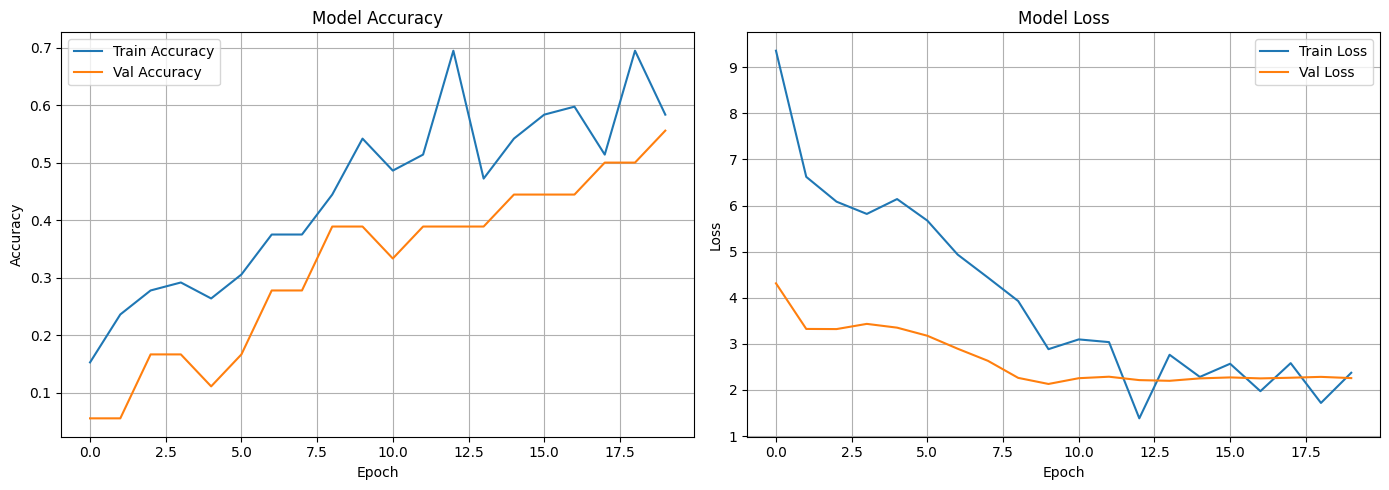

In [22]:
# Plot training history for transfer learning model
plot_training_history(history_tl)

## Step 7: Evaluate Transfer Learning Model


In [23]:
# Evaluate on validation set
val_loss_tl, val_accuracy_tl = transfer_model.evaluate(val_ds)
print(f"\nTransfer Learning - Validation Loss: {val_loss_tl:.4f}")
print(f"Transfer Learning - Validation Accuracy: {val_accuracy_tl:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.3889 - loss: 2.1300

Transfer Learning - Validation Loss: 2.1300
Transfer Learning - Validation Accuracy: 0.3889


## Step 8: Generate Predictions and Classification Report



Transfer Learning - Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.50      0.25      0.33         4
    graviola       0.50      1.00      0.67         1
     guarana       0.20      1.00      0.33         1
     pupunha       0.60      0.75      0.67         4
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.39        18
   macro avg       0.38      0.53      0.38        18
weighted avg       0.42      0.39      0.36        18



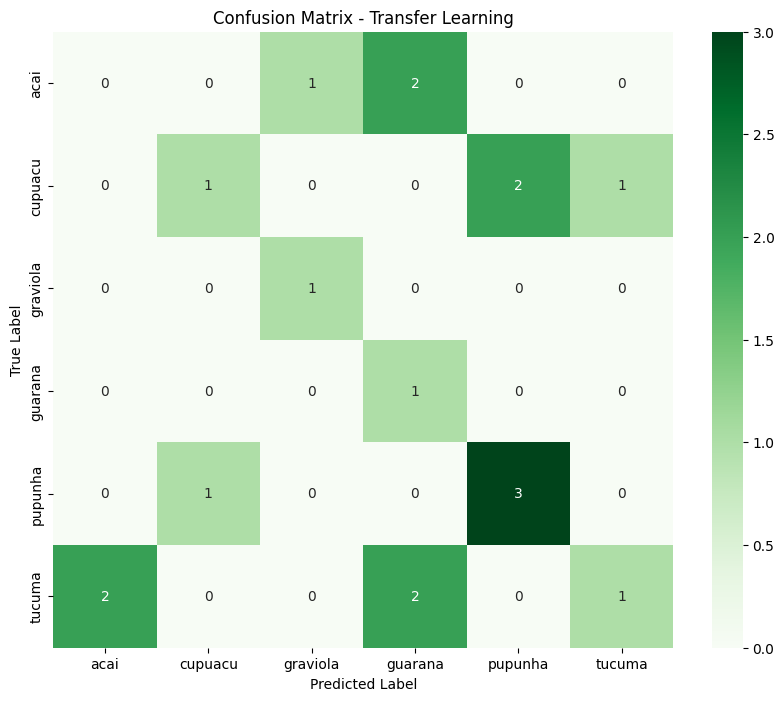

In [24]:
# Get predictions from transfer learning model
y_true_tl = []
y_pred_tl = []

for images, labels in val_ds:
    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(predicted_labels)

# Classification Report
print("\nTransfer Learning - Classification Report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# Confusion Matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Transfer Learning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 9: Compare Performance


In [25]:
# Compare model performances
comparison = pd.DataFrame({
    'Model': ['CNN from Scratch', 'Transfer Learning (VGG16)'],
    'Validation Accuracy': [val_accuracy, val_accuracy_tl],
    'Validation Loss': [val_loss, val_loss_tl]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

# Determine which model performed better
if val_accuracy_tl > val_accuracy:
    improvement = ((val_accuracy_tl - val_accuracy) / val_accuracy) * 100
    print(f"\n✓ Transfer Learning improved accuracy by {improvement:.2f}%")
else:
    print(f"\n✗ CNN from scratch performed better")


MODEL PERFORMANCE COMPARISON
                    Model  Validation Accuracy  Validation Loss
         CNN from Scratch             0.277778         1.728449
Transfer Learning (VGG16)             0.388889         2.129960

✓ Transfer Learning improved accuracy by 40.00%


## Step 10: Save Transfer Learning Model


In [26]:
# Save the transfer learning model
transfer_model.save('vgg16_transfer_learning_model.h5')
print("Transfer learning model saved successfully!")

Transfer learning model saved successfully!


## Step 11: Visualize Sample Predictions


In [27]:
def visualize_predictions(model, dataset, class_names, num_samples=9):
    """Visualize model predictions on sample images"""

    plt.figure(figsize=(12, 12))

    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            true_label = class_names[labels[i]]
            pred_label = class_names[predicted_labels[i]]
            confidence = predictions[i][predicted_labels[i]] * 100

            color = 'green' if labels[i] == predicted_labels[i] else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                     color=color)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize predictions for both models
print("CNN from Scratch Predictions:")
visualize_predictions(model, val_ds, class_names)

print("\nTransfer Learning Predictions:")
visualize_predictions(transfer_model, val_ds, class_names)

Output hidden; open in https://colab.research.google.com to view.